In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
#Import necessary libraries
import pandas as pd
from scipy.stats import randint
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
pd.set_option('display.max_columns', 100)

In [3]:
#load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#data preparation
df = df.drop(columns='customerID').copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
categories = df.columns.to_list()
for i in categories:
    print('the unique values for', i, ' are:\n',df[i].unique(),'\n')

the unique values for gender  are:
 ['Female' 'Male'] 

the unique values for SeniorCitizen  are:
 [0 1] 

the unique values for Partner  are:
 ['Yes' 'No'] 

the unique values for Dependents  are:
 ['No' 'Yes'] 

the unique values for tenure  are:
 [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

the unique values for PhoneService  are:
 ['No' 'Yes'] 

the unique values for MultipleLines  are:
 ['No phone service' 'No' 'Yes'] 

the unique values for InternetService  are:
 ['DSL' 'Fiber optic' 'No'] 

the unique values for OnlineSecurity  are:
 ['No' 'Yes' 'No internet service'] 

the unique values for OnlineBackup  are:
 ['Yes' 'No' 'No internet service'] 

the unique values for DeviceProtection  are:
 ['No' 'Yes' 'No internet service'] 

the unique values for TechSupport  are:
 ['No' 'Yes' 'No internet service

In [7]:
#Convert categorical inputs into numerical equivalent
columns_yes_no = ['Partner', 'Dependents',
            #'PhoneService',
            'PaperlessBilling', 'Churn']
for col in columns_yes_no:
    df[col] = df[col].map({'Yes':1, 'No':0})

columns001 = ['OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies',]
for col in columns001:
    df[col] = df[col].map({'Yes':1, 'No':0, 'No internet service':0})

df['MultipleLines'] = df['MultipleLines'].map({'Yes':1, 'No':0, 'No phone service':0})
#df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df['InternetService'] = df['InternetService'].map({'No':0, 'Fiber optic':2, 'DSL':1})

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['PaymentMethod'] = df['PaymentMethod'].map({'Bank transfer (automatic)':1, 'Credit card (automatic)':1,
                                               'Electronic check':0, 'Mailed check':0})
df['Contract'] = df['Contract'].map({'Month-to-month':1, 'One year':1, 'Two year':2})

#Null values has 0 tenure and therefore has no TotalCharges yet. We assign these values to 0.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [8]:
#note, PaymentMethod could be converted to numerical if we consider automatic or check as payment type
#      Contract could also be converted to numerical if we consider the month of payment instead (month to month = 1, one year = 12, etc.)


X = df.drop(columns=['Churn', 'gender', 'PhoneService'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=16)

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2973 to 6825
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     5634 non-null   int64  
 1   Partner           5634 non-null   int64  
 2   Dependents        5634 non-null   int64  
 3   tenure            5634 non-null   int64  
 4   MultipleLines     5634 non-null   int64  
 5   InternetService   5634 non-null   int64  
 6   OnlineSecurity    5634 non-null   int64  
 7   OnlineBackup      5634 non-null   int64  
 8   DeviceProtection  5634 non-null   int64  
 9   TechSupport       5634 non-null   int64  
 10  StreamingTV       5634 non-null   int64  
 11  StreamingMovies   5634 non-null   int64  
 12  Contract          5634 non-null   int64  
 13  PaperlessBilling  5634 non-null   int64  
 14  PaymentMethod     5634 non-null   int64  
 15  MonthlyCharges    5634 non-null   float64
 16  TotalCharges      5634 non-null   float64
dt

In [10]:
# Create baseline model
model_base = RandomForestClassifier()
model_base.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
y_pred_base = model_base.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred_base)
recall = recall_score(y_test, y_pred_base)
precision = precision_score(y_test, y_pred_base)

print(f'Accuracy score is: {accuracy}')
print(f'Recall score is: {recall}')
print(f'Precision score is: {precision}')

Accuracy score is: 0.7842441447835344
Recall score is: 0.5139664804469274
Precision score is: 0.5859872611464968


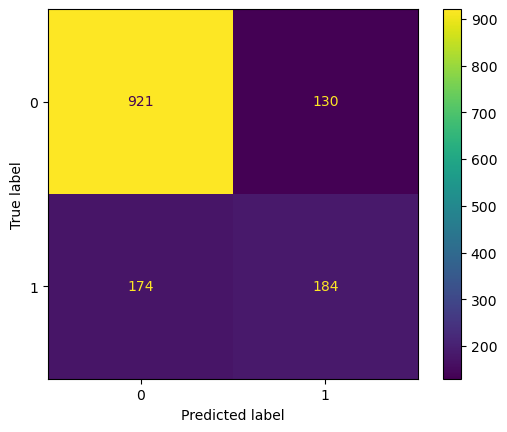

In [13]:
cm = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [14]:
#Create another model with hyperparameter tuning

parameter_dist = {'n_estimators': randint(100, 500),
                  'max_depth': randint(1,20)}

#create random forest model
model = RandomForestClassifier()

# find the best parameter
# use recall as scoring since we want to maximize recall, instead of accuracy

rand_search = RandomizedSearchCV(model,
                                 param_distributions = parameter_dist,
                                 n_iter=50,
                                 n_jobs = -1,
                                 scoring='recall')
#Fit model using the parameters
rand_search.fit(X_train, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(), n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B1B6EC7650>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B1B6EF4C80>},
                   scoring='recall')

In [22]:
# create variable for best model
best_model = rand_search.best_estimator_

# print the hyperparameters
print('best hyperparamters: ', rand_search.best_params_)
print('best recall: ', rand_search.score(X_test, y_test))

best hyperparamters:  {'max_depth': 12, 'n_estimators': 244}
best recall:  0.5363128491620112


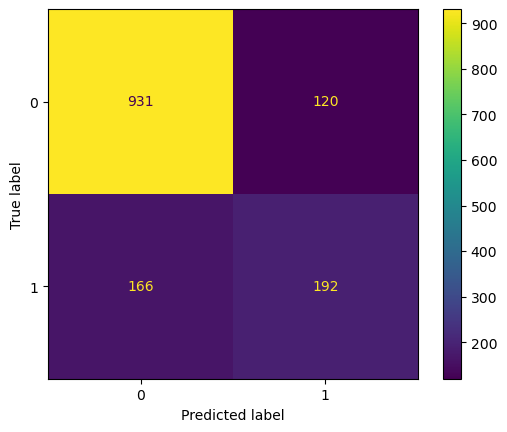

In [16]:
# new model with the parameters of best model

y_pred = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [25]:
y_scores = rand_search.predict_proba(X_test)[:,1]
threshold = 0.3
y_pred2 = (y_scores >= threshold).astype(int)

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1051
           1       0.49      0.77      0.60       358

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.74      0.75      1409

